In [1]:
import pandas as pd

df = pd.read_excel("/Users/sabina/mosstat_dashboard/data/raw/cpi.xlsx", skiprows=3)
df.head()

,Unnamed: 0,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Январь,102.27,101.99,105.79,102.17,102.44,103.25,103.18,102.15,102.70,...,100.77,100.39,101.03,100.42,100.91,100.59,100.91,100.77,100.57,101.72
1,Февраль,101.90,102.09,100.89,100.73,100.32,100.91,100.97,101.17,100.97,...,100.38,100.15,100.52,100.22,100.63,101.72,100.51,100.73,100.21,NaN
2,Март,100.79,102.01,100.70,100.98,100.65,101.38,100.90,100.72,100.90,...,100.25,100.35,100.33,100.33,100.53,107.21,100.36,100.53,100.32,NaN
3,Апрель,100.93,102.29,100.78,101.87,101.72,100.99,100.47,100.61,101.10,...,100.42,100.50,100.36,100.44,100.37,101.61,100.32,100.65,100.47,NaN
4,Май,100.94,102.09,102.18,101.35,100.57,100.55,100.44,100.80,101.72,...,100.55,100.41,100.34,100.48,100.72,100.09,100.37,101.24,100.64,NaN


In [2]:
df = df.rename(columns={"Unnamed: 0": "month"})

In [3]:
df = df.dropna(subset=["month"])

In [4]:
df_long = df.melt(
    id_vars=["month"],
    var_name="year",
    value_name="cpi"
)

In [5]:
df_long = df_long.dropna(subset=["cpi"])

In [6]:
df_long[df_long["cpi"].astype(str).str.contains(r"[^\d,\.]")].head()

,month,year,cpi
481,Декабрь,2026,"101,721)"


In [7]:
df_long["cpi"] = (
    df_long["cpi"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^\d\.]", "", regex=True)
)

In [8]:
df_long["cpi"] = pd.to_numeric(df_long["cpi"], errors="coerce")

In [9]:
df_long = df_long.dropna(subset=["cpi"])

In [10]:
df_long.info()
df_long.head()

<class 'pandas.DataFrame'>
Index: 340 entries, 0 to 481
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   month   340 non-null    str    
 1   year    340 non-null    object 
 2   cpi     340 non-null    float64
dtypes: float64(1), object(1), str(1)
memory usage: 10.6+ KB


,month,year,cpi
0,Январь,2000,102.27
1,Февраль,2000,101.90
2,Март,2000,100.79
3,Апрель,2000,100.93
4,Май,2000,100.94


In [11]:
print(df_long[['month', 'month_num']].head(20))
print(df_long['month_num'].unique())
print(df_long['year'].unique())

KeyError: "['month_num'] not in index"

In [12]:
# словарь для русских месяцев
month_map = {
    'январь': 1,
    'февраль': 2,
    'март': 3,
    'апрель': 4,
    'май': 5,
    'июнь': 6,
    'июль': 7,
    'август': 8,
    'сентябрь': 9,
    'октябрь': 10,
    'ноябрь': 11,
    'декабрь': 12
}

# переводим все в нижний регистр
df_long['month_lower'] = df_long['month'].str.lower()

# создаём числовой столбец
df_long['month_num'] = df_long['month_lower'].map(month_map)

# проверка
print(df_long[['month', 'month_num']].head(15))

       month  month_num
0    Январь         NaN
1    Февраль        2.0
2       Март        3.0
3     Апрель        4.0
4        Май        5.0
5       Июнь        6.0
6       Июль        7.0
7     Август        8.0
8   Сентябрь        9.0
9    Октябрь       10.0
10    Ноябрь       11.0
11   Декабрь       12.0
13   Декабрь       12.0
18   Январь         NaN
19   Февраль        2.0


In [13]:
print(df_long.columns)

Index(['month', 'year', 'cpi', 'month_lower', 'month_num'], dtype='str')


In [15]:
df_long.to_csv("/Users/sabina/mosstat_dashboard/data/processed/cpi_cleaned.csv", index=False)
df = pd.read_csv("/Users/sabina/mosstat_dashboard/data/processed/cpi_cleaned.csv")

In [18]:
import matplotlib.pyplot as plt

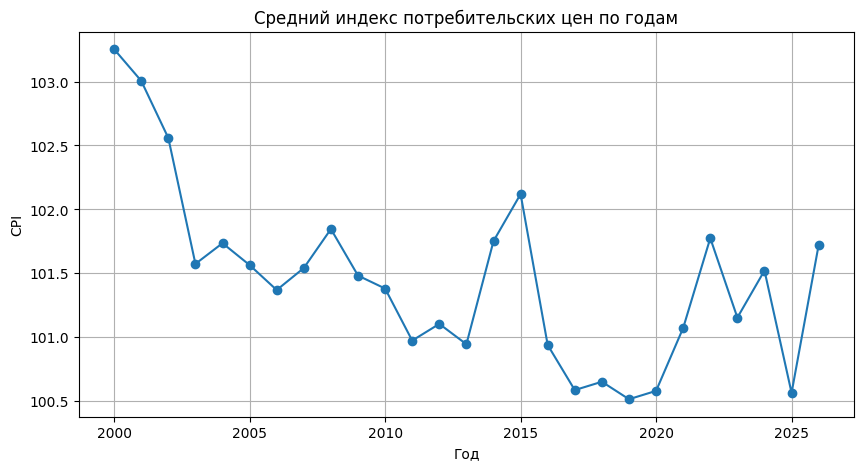

In [19]:
# 4. Средний CPI по годам
df_year = df_long.groupby('year')['cpi'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_year['year'], df_year['cpi'], marker='o')
plt.title('Средний индекс потребительских цен по годам')
plt.xlabel('Год')
plt.ylabel('CPI')
plt.grid(True)
plt.show()

In [20]:
# 5. Сезонная динамика CPI
df_plot = df_long.dropna(subset=['month_num'])
plt.figure(figsize=(12,6))
sns.lineplot(data=df_plot, x='month_num', y='cpi', hue='year', palette='tab20')
plt.title('Сезонная динамика CPI по месяцам')
plt.xlabel('Месяц')
plt.ylabel('CPI')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x600 with 0 Axes>

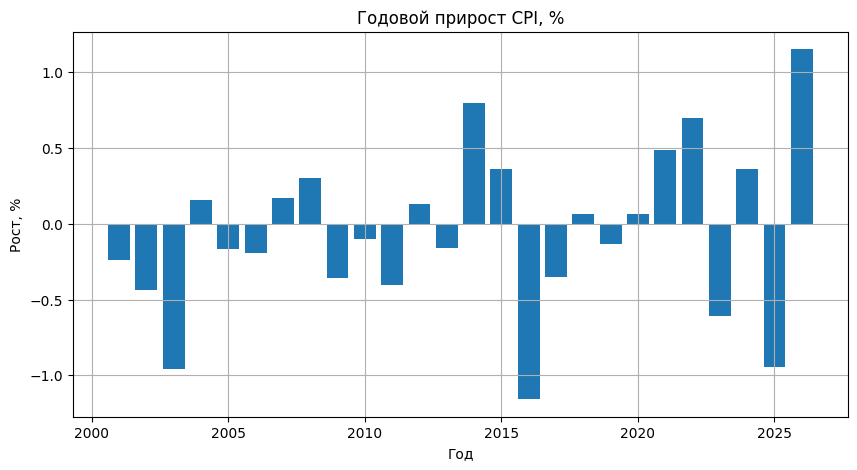

In [21]:
# 6. Годовой прирост CPI (инфляция)
df_year['cpi_growth'] = df_year['cpi'].pct_change() * 100

plt.figure(figsize=(10,5))
plt.bar(df_year['year'], df_year['cpi_growth'])
plt.title('Годовой прирост CPI, %')
plt.xlabel('Год')
plt.ylabel('Рост, %')
plt.grid(True)
plt.show()

1. Средний CPI по годам показывает общий рост цен, с резкими скачками в кризисные периоды:
   - 2008–2009: мировой финансовый кризис
   - 2014–2015: падение рубля и рост цен на импортные товары
   - 2020: пандемия COVID-19

2. Сезонная динамика показывает небольшие колебания:
   - Летом и зимой цены выше, возможно из-за сезонных продуктов и коммунальных услуг
   - Весной и осенью рост цен более плавный

3. Годовой прирост CPI (инфляция) неравномерен:
   - Пики совпадают с кризисными годами
   - В стабильные периоды рост умеренный (2–5%)

4. Гипотезы:
   - Резкие скачки CPI связаны с девальвацией рубля, внешними экономическими шоками или ростом цен на импортные товары
   - Плавный рост отражает нормальное повышение цен на базовые товары и услуги
"""